In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

BASE='/content/drive/MyDrive/Phishing_Detection_Project'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Mounted at /content/drive


In [2]:
df = pd.read_csv(f"{BASE}/data/raw/phishing.csv")
df = df.drop(columns=['Index'])

print(df.shape)

(11054, 31)


In [3]:
corr = df.corr()

target_col = df.columns[-1]

target_corr = corr[target_col].sort_values(ascending=False)

print(target_corr)

class                  1.000000
HTTPS                  0.714704
AnchorURL              0.692895
PrefixSuffix-          0.348588
WebsiteTraffic         0.346003
SubDomains             0.298231
RequestURL             0.253478
LinksInScriptTags      0.248415
ServerFormHandler      0.221380
GoogleIndex            0.129000
AgeofDomain            0.121402
PageRank               0.104593
UsingIP                0.094033
StatsReport            0.079632
DNSRecording           0.075579
LongURL                0.057661
Symbol@                0.052994
StatusBarCust          0.041878
NonStdPort             0.036461
LinksPointingToPage    0.032694
InfoEmail              0.018039
DisableRightClick      0.012675
UsingPopupWindow       0.000136
Favicon               -0.000231
IframeRedirection     -0.003362
WebsiteForwarding     -0.020151
Redirecting//         -0.038885
HTTPSDomainURL        -0.040096
AbnormalURL           -0.060751
ShortURL              -0.067931
DomainRegLen          -0.225879
Name: cl

In [4]:
selected = target_corr[abs(target_corr) > 0.1].index.tolist()

print("Selected Features:")
print(selected)
print("Count:", len(selected))

Selected Features:
['class', 'HTTPS', 'AnchorURL', 'PrefixSuffix-', 'WebsiteTraffic', 'SubDomains', 'RequestURL', 'LinksInScriptTags', 'ServerFormHandler', 'GoogleIndex', 'AgeofDomain', 'PageRank', 'DomainRegLen']
Count: 13


In [5]:
new_df = df[selected]

print(new_df.shape)
new_df.head()

(11054, 13)


,class,HTTPS,AnchorURL,PrefixSuffix-,WebsiteTraffic,SubDomains,RequestURL,LinksInScriptTags,ServerFormHandler,GoogleIndex,AgeofDomain,PageRank,DomainRegLen
0,-1,1,0,-1,0,0,1,-1,-1,1,-1,-1,-1
1,-1,-1,0,-1,1,-1,1,-1,-1,1,1,-1,-1
2,-1,-1,0,-1,1,-1,-1,0,-1,1,-1,-1,1
3,1,1,0,-1,0,1,1,0,-1,1,-1,-1,-1
4,1,1,0,-1,1,1,1,0,-1,1,1,-1,-1


In [6]:
new_df.to_csv(f"{BASE}/data/processed/engineered_data.csv", index=False)

print("Saved engineered_data.csv")

Saved engineered_data.csv


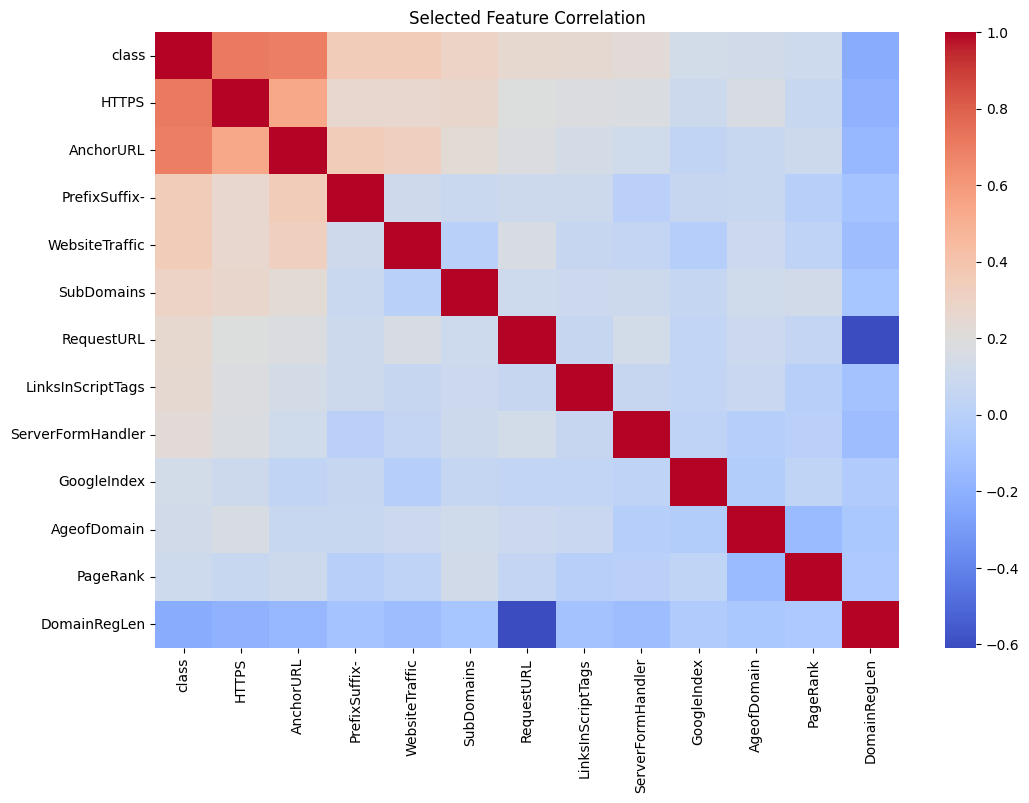

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(new_df.corr(), cmap='coolwarm')
plt.title("Selected Feature Correlation")
plt.show()